# First Simple CNN Model

Start with the simplest next model that can plausibly beat logistic + MFCC:

- a small CNN on 2D audio representations of each breathing cycle

Plan:

**1. Fix the modelling unit**

- One row = one cycle_filename
- One label = disease for that cycle’s patient


**2. Turn each cycle .wav into a fixed-size 2D input**

Use a mel spectrogram as a 2D array:

- x-axis = time
- y-axis = frequency bands
- values = energy

**3. Build a very small CNN first**

- 2 convolution layers
- max pooling
- flatten
- dense
- softmax output

## Imports

In [1]:
import os
from pathlib import Path
import sys

# Move notebook working directory to the project root
os.chdir("/Users/keira/code/mi-mi-mia/smart-stethoscope")

# Make sure Python can import the package
sys.path.insert(0, str(Path.cwd()))

print("Current working directory:", Path.cwd())
print("raw_data exists:", Path("raw_data").exists())
print("preprocessed_data exists:", Path("preprocessed_data").exists())

Current working directory: /Users/keira/code/mi-mi-mia/smart-stethoscope
raw_data exists: True
preprocessed_data exists: True


In [2]:

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


from smart_stethoscope.ml_logic.data_loading import load_data
from smart_stethoscope.ml_logic.preprocessing import preprocess_tabular_data

## 0. Preprocessing

In [3]:
# Load the full dataframe
df = load_data()

print("Raw df shape:", df.shape)
print(df.columns.tolist())


✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...
Raw df shape: (6898, 13)
['start', 'end', 'crackles', 'wheezes', 'filename', 'chest_location', 'cycle_filename', 'disease', 'age', 'sex', 'adult_bmi', 'child_weight', 'child_height']


In [7]:
# 2. Run preprocessing to get split outputs
X_train_tab, X_val_tab, X_test_tab, y_train, y_val, y_test, train_cycle_filenames, val_cycle_filenames, test_cycle_filenames = preprocess_tabular_data(df)

print("X_train_tab shape:", X_train_tab.shape)
print("X_test_tab shape:", X_test_tab.shape)
print("Number of train cycle filenames:", len(train_cycle_filenames))
print("Number of test cycle filenames:", len(test_cycle_filenames))

X_train_tab shape: (4889, 14)
X_test_tab shape: (1054, 14)
Number of train cycle filenames: 4889
Number of test cycle filenames: 1054


/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## 1. Convert one cycle into a 2D array

In [8]:
# Define a function to transform wav file to a mel spectrogram

def wav_to_mel_spec(
    cycle_filename,
    audio_folder,
    n_mels=64,
    max_time_steps=200
):

    """
    Convert one breathing cycle .wav file into a fixed-size mel spectrogram.

    Parameters
    ----------
    cycle_filename : str
        Breathing cycle filename without the .wav extension.
        Example: '101_1b1_Al_sc_Meditron_0'
    audio_folder : str or Path
        Folder containing extracted breathing cycle .wav files.
    n_mels : int, default=64
        Number of mel frequency bins.
    max_time_steps : int, default=200
        Fixed width for the spectrogram.
        If spectrogram is shorter, pad with zeros.
        If longer, crop.

    Returns
    -------
    mel_spec_db : np.ndarray
        2D array of shape (n_mels, max_time_steps)
    """

    # Build full file path
    file_path = Path(audio_folder) / f"{cycle_filename}.wav"

    # Load audio at original sample rate
    signal, sr = librosa.load(file_path, sr=None)

    # Convert waveform to mel spectrogram (power scale)
    mel_spec = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=n_mels
    )

    # Convert to decibel scale for better modelling / visualisation
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Current shape is (n_mels, time_steps)
    current_time_steps = mel_spec_db.shape[1]

    # Pad with zeros on the right if too short
    if current_time_steps < max_time_steps:
        pad_width = max_time_steps - current_time_steps
        mel_spec_db = np.pad(
            mel_spec_db,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )

    # Crop on the right if too long
    elif current_time_steps > max_time_steps:
        mel_spec_db = mel_spec_db[:, :max_time_steps]

    return mel_spec_db

In [9]:
# Select one example cycle from the train split
example_cycle = train_cycle_filenames[0]
print("Example cycle filename:", example_cycle)

Example cycle filename: 148_1b1_Al_sc_Meditron_0


In [10]:
# Convert that one cycle into a mel spectrogram
cycle_audio_path = "preprocessed_data/audio_breathing_cycles"

example_mel = wav_to_mel_spec(
    cycle_filename=example_cycle,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

print("Mel spectrogram shape:", example_mel.shape)

Mel spectrogram shape: (64, 200)


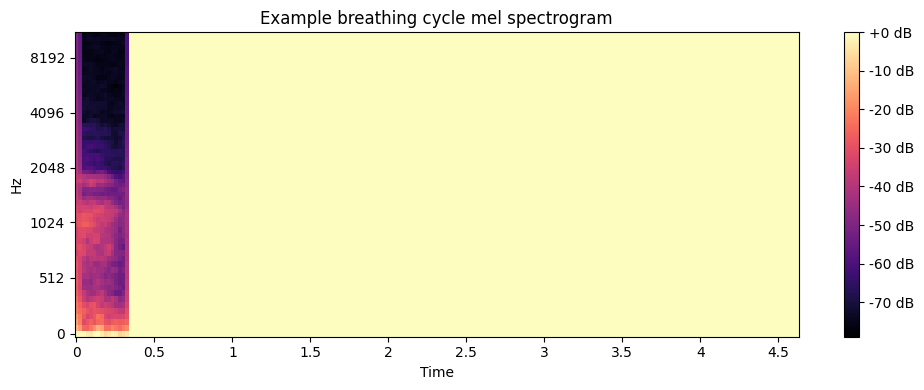

In [11]:
# Plot the spec
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    example_mel,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Example breathing cycle mel spectrogram")
plt.tight_layout()
plt.show()

## 2. Convert all train and test cycles

In [12]:
# Assumes these already exist from previous steps:
# - train_cycle_filenames
# - test_cycle_filenames
# - wav_to_mel_spec()
# - cycle_audio_path

def build_mel_dataset(
    cycle_filenames,
    audio_folder,
    n_mels=64,
    max_time_steps=200):
    """
    Convert a list/array of cycle filenames into a 4D tensor for CNN input.

    Parameters
    ----------
    cycle_filenames : iterable of str
        Cycle filenames without .wav extension
    audio_folder : str or Path
        Folder containing cycle .wav files
    n_mels : int, default=64
        Number of mel bins
    max_time_steps : int, default=200
        Fixed spectrogram width

    Returns
    -------
    X : np.ndarray
        CNN-ready tensor of shape (n_samples, n_mels, max_time_steps, 1)
    """

    mel_specs = []

    for cycle_filename in cycle_filenames:
        # convert each wav to a mel spec
        mel = wav_to_mel_spec(
            cycle_filename=cycle_filename,
            audio_folder=audio_folder,
            n_mels=n_mels,
            max_time_steps=max_time_steps
        )
        # add each 2D array to the list
        mel_specs.append(mel)

    # Stack into one 3D array: (n_samples, n_mels, max_time_steps)
    X = np.stack(mel_specs)

    # Add channel dimension for expected CNN shape: (n_samples, n_mels, max_time_steps, 1)
    X = X[..., np.newaxis]

    return X

In [13]:
# Build train and test image tensors
cycle_audio_path = "preprocessed_data/audio_breathing_cycles"

X_train_img = build_mel_dataset(
    cycle_filenames=train_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

X_test_img = build_mel_dataset(
    cycle_filenames=test_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

print("X_train_img shape:", X_train_img.shape)
print("X_test_img shape:", X_test_img.shape)
print("Expected CNN input shape per sample:", X_train_img[0].shape)

X_train_img shape: (4889, 64, 200, 1)
X_test_img shape: (1054, 64, 200, 1)
Expected CNN input shape per sample: (64, 200, 1)


## 3. Encode labels for CNN

In [14]:
# Check shape of data
print("y_train shape before encoding:", y_train.shape)
print("y_test shape before encoding:", y_test.shape)

# Check class labels
print("Unique train labels:", sorted(y_train.unique()))
print("Unique test labels:", sorted(y_test.unique()))

# Calculate number of classes
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

y_train shape before encoding: (4889,)
y_test shape before encoding: (1054,)
Unique train labels: [0, 1, 2, 3, 4, 5]
Unique test labels: [0, 1, 2, 3, 4, 5]
Number of classes: 6


In [15]:
# Convert integer labels to one-hot encoded arrays
# Example: class 2 becomes [0, 0, 1, 0, 0, 0]
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Check the new shapes
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

# Look at one example
print("First raw label:", y_train.iloc[0])
print("First one-hot label:", y_train_cat[0])

y_train_cat shape: (4889, 6)
y_test_cat shape: (1054, 6)
First raw label: 2
First one-hot label: [0. 0. 1. 0. 0. 0.]


## 4. Build a very small CNN

Build a small CNN for multi-class breathing cycle classification:

In [16]:
# Check the shape of one training example
# Expected shape per sample = (64, 200, 1)
# 64 mel bins (height), 200 time steps (width), 1 channel (like a grayscale image)
print("Single training example shape:", X_train_img[0].shape)

# Work out the input shape for the CNN
# Keras wants the shape of ONE sample, not the full dataset
input_shape = X_train_img.shape[1:]

print("CNN input shape:", input_shape)
print("Number of output classes:", num_classes)

Single training example shape: (64, 200, 1)
CNN input shape: (64, 200, 1)
Number of output classes: 6


In [17]:
# Build a small sequential CNN

# ------------------------------------------------
# Architecture:
# 1. Convolution layer
# 2. Max pooling
# 3. Convolution layer
# 4. Max pooling
# 5. Flatten
# 6. Dense hidden layer
# 7. Softmax output layer
# ------------------------------------------------

cnn_model = models.Sequential()

# First convolution block
cnn_model.add(layers.Input(shape=input_shape))
cnn_model.add(
    layers.Conv2D(
        filters=16,                 # number of filters / feature detectors
        kernel_size=(3, 3),         # small 2D window scanning the image
        activation="relu",          # non-linear activation
        padding="same"              # keep output width/height similar
    )
)
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # reduce spatial size

# Second convolution block
cnn_model.add(layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )
)
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten 2D feature maps into 1D vector
cnn_model.add(layers.GlobalAveragePooling2D())

# Dense hidden layer
cnn_model.add(layers.Dense(32,activation="relu"))

# Dropout to reduce overfitting a bit
cnn_model.add(layers.Dropout(0.3))

# Output layer
# num_classes = 6, so softmax returns 6 probabilities
cnn_model.add(layers.Dense(num_classes, activation="softmax"))

# Compile the model
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

2026-03-20 15:03:40.969620: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-20 15:03:40.969812: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-20 15:03:40.969825: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-20 15:03:40.970217: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-20 15:03:40.970238: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 200, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,054 (23.65 KB)

 Trainable params: 6,054 (23.65 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train and compare performance

In [18]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the model
history = cnn_model.fit(
    X_train_img,
    y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = cnn_model.evaluate(X_test_img, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/15


2026-03-20 15:03:45.603562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6878 - loss: 2.2532 - val_accuracy: 0.8957 - val_loss: 0.6421
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7847 - loss: 0.9716 - val_accuracy: 0.8957 - val_loss: 0.5758
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7827 - loss: 0.9647 - val_accuracy: 0.8957 - val_loss: 0.5533
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8182 - loss: 0.8104 - val_accuracy: 0.8957 - val_loss: 0.5355
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8179 - loss: 0.7922 - val_accuracy: 0.8957 - val_loss: 0.5301
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8197 - loss: 0.7698 - val_accuracy: 0.8957 - val_loss: 0.5227
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8195 - loss: 0.7672 - val_accuracy: 0.8957 - val_loss: 0.5030
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8195 - loss: 0.7525 - val_accuracy: 0.895

Get predictions and inspect performance:

In [19]:
# Predict class probabilities
y_pred_probs = cnn_model.predict(X_test_img)

# Convert probabilities to class labels
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded y_test back to integer labels
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.85      1.00      0.92       891
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        26
           5       0.00      0.00      0.00        13

    accuracy                           0.85      1054
   macro avg       0.14      0.17      0.15      1054
weighted avg       0.71      0.85      0.77      1054



## Iterations

### Iteration 1️⃣: CNN with class weights

In [20]:
# Convert one-hot back to integer labels
y_train_int = np.argmax(y_train_cat, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)

Class weights: {0: 3.8435534591194966, 1: 0.19946960424316607, 2: 4.879241516966068, 3: 11.809178743961352, 4: 3.573830409356725, 5: 6.365885416666667}


In [21]:
# Train model with class weights
history = cnn_model.fit(
    X_train_img,
    y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_accuracy = cnn_model.evaluate(X_test_img, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.2772 - loss: 2.0179 - val_accuracy: 0.5153 - val_loss: 1.4068
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2774 - loss: 1.8617 - val_accuracy: 0.3149 - val_loss: 1.5416
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3099 - loss: 1.7204 - val_accuracy: 0.3016 - val_loss: 1.4673
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5427 - loss: 1.3918
Test loss: 1.391762375831604
Test accuracy: 0.5426945090293884


In [22]:
# Predict and evaluate
y_pred_probs = cnn_model.predict(X_test_img)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.09      0.39      0.15        57
           1       0.96      0.61      0.75       891
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        26
           5       0.03      0.62      0.06        13

    accuracy                           0.54      1054
   macro avg       0.18      0.27      0.16      1054
weighted avg       0.82      0.54      0.64      1054



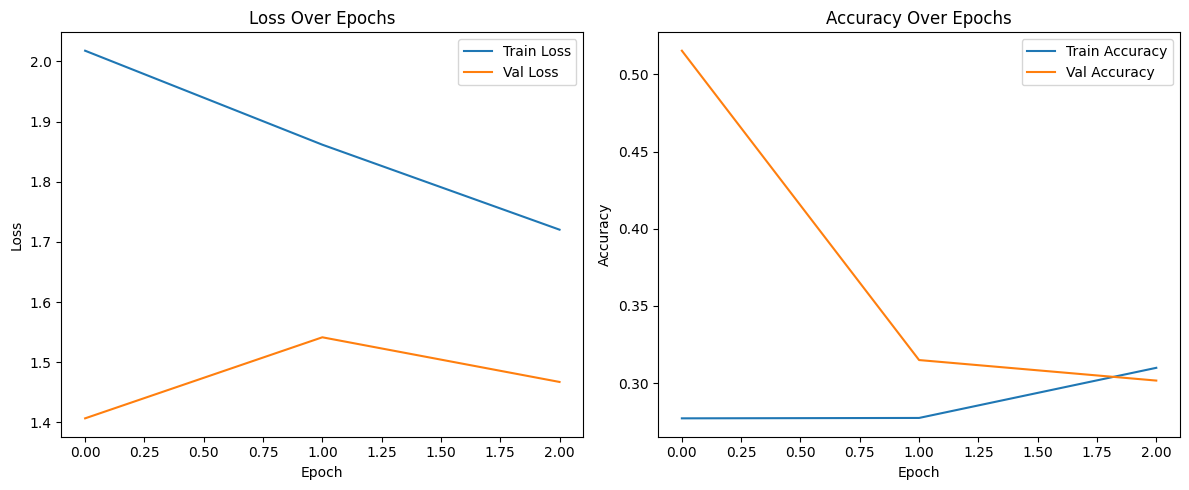

In [23]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### ⭐️ Best So Far ⭐️
### Iteration 2️⃣: We need a kinder patience parameter in EarlyStopping

In [24]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5, # instead of 3
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_img,
    y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_accuracy = cnn_model.evaluate(X_test_img, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

# Predict and evaluate
y_pred_probs = cnn_model.predict(X_test_img)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1984 - loss: 1.9259 - val_accuracy: 0.3333 - val_loss: 1.5786
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2759 - loss: 1.7294 - val_accuracy: 0.3078 - val_loss: 1.3916
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2580 - loss: 1.6689 - val_accuracy: 0.4356 - val_loss: 1.4943
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2838 - loss: 1.6157 - val_accuracy: 0.2485 - val_loss: 1.8623
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2736 - loss: 1.5507 - val_accuracy: 0.1391 - val_loss: 1.6680
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2864 - loss: 1.5479 - val_accuracy: 0.2566 - val_loss: 1.8372
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2807 - loss: 1.5581 - val_accuracy: 0.4683 - val_loss: 1.4478
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4165 - loss: 1.3339
Test loss: 1.33394372463

In [25]:
# ⭐️ SAVE MVP MODEL
print("Current working directory:", os.getcwd())

os.makedirs("models", exist_ok=True)
cnn_model.save("models/best_cnn_model.keras")

print("Saved to:", os.path.abspath("models/best_cnn_model.keras"))
print("Exists now:", os.path.exists("models/best_cnn_model.keras"))
print("Folder contents:", os.listdir("models"))

Current working directory: /Users/keira/code/mi-mi-mia/smart-stethoscope
Saved to: /Users/keira/code/mi-mi-mia/smart-stethoscope/models/best_cnn_model.keras
Exists now: True
Folder contents: ['best_cnn_model.keras', 'class_names.json', 'preprocessing_config.json', 'logistic_baseline.pkl']


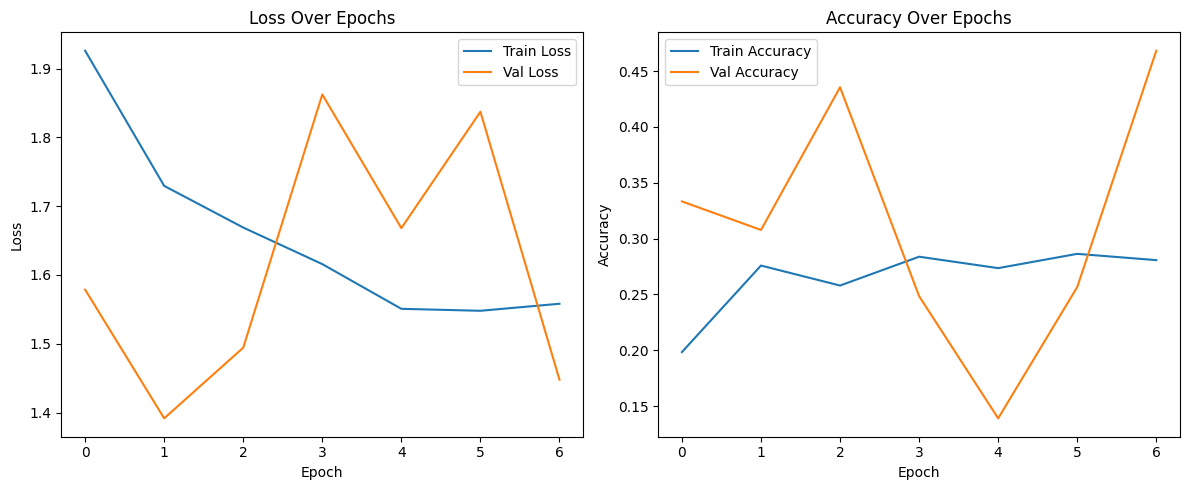

In [26]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
print(len(history.history["loss"]))

7


### Iteration 3️⃣: A stronger CNN (increase filters)

In [28]:
input_shape = X_train_img.shape[1:]

cnn_model = models.Sequential()

# First convolution block
cnn_model.add(layers.Input(shape=input_shape))
cnn_model.add(
    layers.Conv2D(
        filters=32,                 # increased from 16
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )
)
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Second convolution block
cnn_model.add(
    layers.Conv2D(
        filters=64,                 # increased from 32
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )
)
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Global average pooling keeps parameter count low
cnn_model.add(layers.GlobalAveragePooling2D())

# Dense hidden layer
cnn_model.add(layers.Dense(32, activation="relu"))

# Dropout
cnn_model.add(layers.Dropout(0.3))

# Output layer
cnn_model.add(layers.Dense(num_classes, activation="softmax"))

# Compile model
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 200, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 100, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,094 (82.40 KB)

 Trainable params: 21,094 (82.40 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_img,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1890 - loss: 4.9961 - val_accuracy: 0.0859 - val_loss: 1.5221
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1982 - loss: 2.9988 - val_accuracy: 0.5767 - val_loss: 1.5482
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1780 - loss: 2.6674 - val_accuracy: 0.0695 - val_loss: 1.7854
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1989 - loss: 2.4317 - val_accuracy: 0.3793 - val_loss: 1.7152
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1851 - loss: 2.2545 - val_accuracy: 0.0624 - val_loss: 2.0139
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.1621 - loss: 2.1904 - val_accuracy: 0.4591 - val_loss: 1.4826
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1969 - loss: 2.1203 - val_accuracy: 0.7004 - val_loss: 1.2199
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.2104 - loss: 2.1215 - val_accu

In [30]:
# Predict and evaluate
y_pred_probs = cnn_model.predict(X_test_img)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.90      0.85      0.87       891
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        26
           5       0.03      0.38      0.06        13

    accuracy                           0.72      1054
   macro avg       0.16      0.20      0.16      1054
weighted avg       0.76      0.72      0.74      1054



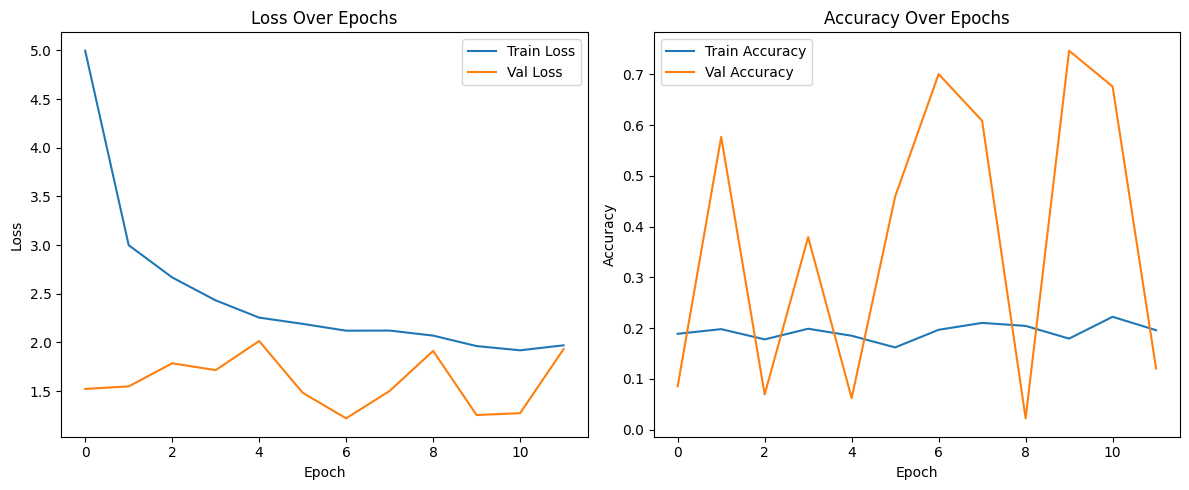

In [31]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Recompute predictions from the CURRENT trained model
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Evaluate directly in Keras
test_loss, test_accuracy = cnn_model.evaluate(X_test_img, y_test_cat, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

# 2. Predict on test set using the SAME model
y_pred_probs = cnn_model.predict(X_test_img, verbose=1)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

# 3. Convert one-hot test labels back to integer labels
y_test_int = np.argmax(y_test_cat, axis=1)

# 4. Sanity check: sklearn accuracy should match Keras accuracy closely
print("Sklearn accuracy:", accuracy_score(y_test_int, y_pred_cnn))

# 5. Classification report
print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

# 6. Optional: confusion matrix
print(confusion_matrix(y_test_int, y_pred_cnn))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7192 - loss: 1.3098
Test loss: 1.3098289966583252
Test accuracy: 0.7191650867462158
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Sklearn accuracy: 0.7191650853889943
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.90      0.85      0.87       891
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        26
           5       0.03      0.38      0.06        13

    accuracy                           0.72      1054
   macro avg       0.16      0.20      0.16      1054
weighted avg       0.76      0.72      0.74      1054

[[  0  21   0   0   3  33]
 [  0 753   0   0  52  86]
 [  0  17   0   0   1  25]
 [  0  21   0   0   1   2]
 [  0  22   0   0   0   4]
 [  0   4   0   0   4   5]]


### Testing new CNN functions...

In [33]:
from smart_stethoscope.ml_logic.model import train_cnn_model

In [34]:
cnn_model, history, metrics, y_pred = train_cnn_model(
    X_train_img=X_train_img,
    X_test_img=X_test_img,
    y_train=y_train,
    y_test=y_test
)

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1457 - loss: 6.2307 - val_accuracy: 0.0317 - val_loss: 1.9077
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1143 - loss: 2.4517 - val_accuracy: 0.0317 - val_loss: 2.0699
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0780 - loss: 1.9039 - val_accuracy: 0.0276 - val_loss: 1.8511
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0767 - loss: 1.8900 - val_accuracy: 0.0327 - val_loss: 1.9140
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1537 - loss: 1.8661 - val_accuracy: 0.7239 - val_loss: 1.3871
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1376 - loss: 1.8361 - val_accuracy: 0.0358 - val_loss: 1.9061
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1895 - loss: 1.8181 - val_accuracy: 0.0429 - val_loss: 1.7885
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2092 - loss: 1.7818 - val_accu